## Import libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

## CUSTOM TEXT CORPUS

In [55]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences

machine learning algorithms learn patterns from data
neural networks are inspired by the human brain
artificial intelligence is changing modern industries
deep learning powers image recognition systems
natural language processing enables text understanding
data science combines statistics and programming
machine learning improves prediction accuracy
language models generate realistic text sequences
artificial intelligence helps automate repetitive tasks
deep neural networks can solve complex problems
supervised learning requires labeled datasets
unsupervised learning discovers hidden patterns
reinforcement learning learns through rewards
text generation is an exciting research area
'''

## TOKENIZATION

In [56]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 88


##  CREATE N-GRAM SEQUENCES

In [57]:
input_sequences = []

for line in corpus.split("\n"):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print("Total Sequences:", len(input_sequences))

Total Sequences: 106


## Padding

In [58]:
max_sequence_len = max(len(x) for x in input_sequences)

input_sequences = np.array(
    pad_sequences(
        input_sequences,
        maxlen=max_sequence_len,
        padding='pre'
    )
)

print("Maximum Sequence Length:", max_sequence_len)

Maximum Sequence Length: 8


## Create X and y

In [59]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = to_categorical(y, num_classes=total_words)

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (106, 7)
Y Shape: (106, 88)


## Build Vanilla RNN Model

In [60]:
def build_rnn():

    model = Sequential()

    model.add(
        Embedding(
            input_dim=total_words,
            output_dim=128,
            input_length=max_sequence_len-1
        )
    )

    model.add(SimpleRNN(128))

    model.add(
        Dense(
            total_words,
            activation='softmax'
        )
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## Build LSTM Model

In [61]:
def build_lstm():

    model = Sequential()

    model.add(
        Embedding(
            total_words,
            128,
            input_length=max_sequence_len-1
        )
    )

    model.add(LSTM(128))

    model.add(
        Dense(
            total_words,
            activation='softmax'
        )
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## Build GRU Model

In [62]:
def build_gru():

    model = Sequential()

    model.add(
        Embedding(
            total_words,
            128,
            input_length=max_sequence_len-1
        )
    )

    model.add(GRU(128))

    model.add(
        Dense(
            total_words,
            activation='softmax'
        )
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## Create Models

In [63]:
rnn_model = build_rnn()
lstm_model = build_lstm()
gru_model = build_gru()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Train Models


In [64]:
epochs = 200

history_rnn = rnn_model.fit(
    X,
    y,
    epochs=epochs,
    validation_split=0.2,
    verbose=1
)

history_lstm = lstm_model.fit(
    X,
    y,
    epochs=epochs,
    validation_split=0.2,
    verbose=1
)

history_gru = gru_model.fit(
    X,
    y,
    epochs=epochs,
    validation_split=0.2,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 192ms/step - accuracy: 0.0000e+00 - loss: 4.4858 - val_accuracy: 0.0000e+00 - val_loss: 4.4638
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0952 - loss: 4.3691 - val_accuracy: 0.1364 - val_loss: 4.4728
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1429 - loss: 4.2513 - val_accuracy: 0.1364 - val_loss: 4.5184
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1071 - loss: 4.1412 - val_accuracy: 0.1364 - val_loss: 4.6292
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0833 - loss: 4.0351 - val_accuracy: 0.1364 - val_loss: 4.7735
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0833 - loss: 3.9307 - val_accuracy: 0.1364 - val_loss: 4.8362
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1548 - loss: 3.8353 - val_accuracy: 0.1364 - val_loss: 4.8242
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2024 - loss: 3.7352 - val_accuracy: 0.1364 - 

## Training Loss Comparison Graph

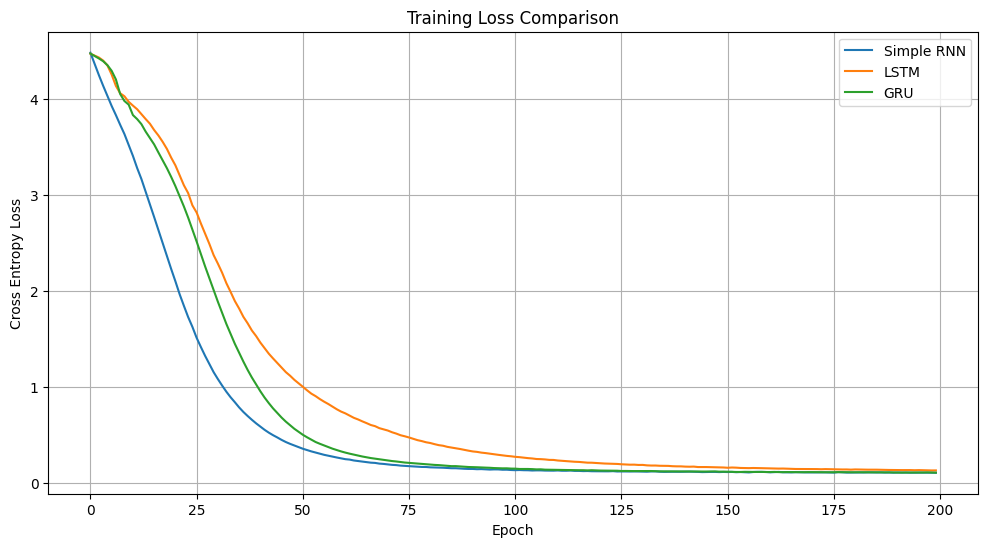

In [65]:
plt.figure(figsize=(12,6))

plt.plot(
    history_rnn.history['loss'],
    label='Simple RNN'
)

plt.plot(
    history_lstm.history['loss'],
    label='LSTM'
)

plt.plot(
    history_gru.history['loss'],
    label='GRU'
)

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True)

plt.show()

## Validation Accuracy Graph

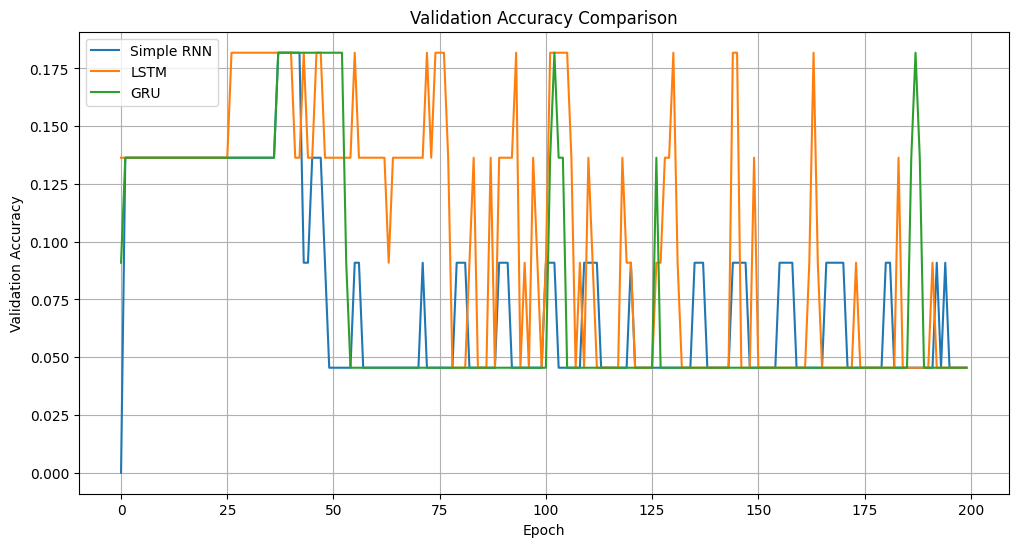

In [66]:
plt.figure(figsize=(12,6))

plt.plot(
    history_rnn.history['val_accuracy'],
    label='Simple RNN'
)

plt.plot(
    history_lstm.history['val_accuracy'],
    label='LSTM'
)

plt.plot(
    history_gru.history['val_accuracy'],
    label='GRU'
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

## Accuracy Comparison

In [67]:
comparison_df = pd.DataFrame({

    "Model":[
        "Simple RNN",
        "LSTM",
        "GRU"
    ],

    "Train Accuracy":[
        history_rnn.history['accuracy'][-1],
        history_lstm.history['accuracy'][-1],
        history_gru.history['accuracy'][-1]
    ],

    "Validation Accuracy":[
        history_rnn.history['val_accuracy'][-1],
        history_lstm.history['val_accuracy'][-1],
        history_gru.history['val_accuracy'][-1]
    ]
})

print(comparison_df)

        Model  Train Accuracy  Validation Accuracy
0  Simple RNN        0.940476             0.045455
1        LSTM        0.928571             0.045455
2         GRU        0.952381             0.045455


## Text Generation Function

In [68]:
def generate_text(
    model,
    seed_text,
    next_words=10
):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len-1,
            padding='pre'
        )

        predicted_probs = model.predict(
            token_list,
            verbose=0
        )

        predicted_index = np.argmax(predicted_probs)

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted_index:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

## Generate Text

In [70]:
seed = "artificial intelligence"

print("RNN OUTPUT")
print(generate_text(rnn_model, seed, 10))

print("\nLSTM OUTPUT")
print(generate_text(lstm_model, seed, 10))

print("\nGRU OUTPUT")
print(generate_text(gru_model, seed, 10))

RNN OUTPUT
artificial intelligence is changing modern industries recognition systems the next word for

LSTM OUTPUT
artificial intelligence is changing modern industries industries industries lstm lstm dependencies data

GRU OUTPUT
artificial intelligence is changing modern industries industries industries industries industries sentences word
